### Import dependencies

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from gym_examples.envs.cavity import CavityEnv
from gymnasium.wrappers import ClipAction

from stable_baselines3 import PPO, DDPG, A2C
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

# Custom policy
import torch as th
import torch.nn as nn
from sb3_contrib.ppo_recurrent.policies import RecurrentActorCriticPolicy

from datetime import datetime

In [2]:
import oreonspy as ons
ons.__version__

'4.1.0'




### Make the environment

In [47]:
#env = gym.make('gym_examples/Cavity-v0', max_episode_steps=400, random_L=True)
env = gym.make('gym_examples/Cavity-v0', t_a = np.sqrt(0.029), r_a = np.sqrt(0.99), r_b = np.sqrt(0.999), L=.60, f_c = 1600000, max_episode_steps=1024, random_L=True, in_resonance_L=True, P_noise_sigma=0.01, PDH_noise_sigma=0.01) #, displacement_factor=0.05
#env = ClipAction(env)

### Create custom policy

In [48]:
class CustomMlpExtractor(nn.Module):
    def __init__(self, feature_dim: int, net_arch=(400, 300), activation_fn=nn.ReLU):
        super(CustomMlpExtractor, self).__init__()

        # Shared layers
        shared_layers = []
        last_layer_dim_shared = feature_dim
        for layer_size in net_arch:
            shared_layers.append(nn.Linear(last_layer_dim_shared, layer_size))
            shared_layers.append(activation_fn())
            last_layer_dim_shared = layer_size
        self.shared_net = nn.Sequential(*shared_layers)

        # Separate policy and value networks
        self.policy_net = nn.Sequential(
            nn.Linear(last_layer_dim_shared, 64),
            activation_fn(),
        )
        self.value_net = nn.Sequential(
            nn.Linear(last_layer_dim_shared, 64),
            activation_fn(),
        )

    def forward(self, features: th.Tensor):
        shared_latent = self.shared_net(features)
        return self.policy_net(shared_latent), self.value_net(shared_latent)

class CustomActorCriticPolicy(RecurrentActorCriticPolicy):
    def __init__(self, *args, **kwargs):
        super(CustomActorCriticPolicy, self).__init__(*args, **kwargs)
        
        # Replace MLP extractor
        self.mlp_extractor = CustomMlpExtractor(
            feature_dim=self.features_dim,
            net_arch=(400, 300),  # your custom arch
            activation_fn=nn.ReLU
        )

In [49]:
callback_on_best = StopTrainingOnRewardThreshold(reward_threshold=700, verbose=1)
eval_callback = EvalCallback(env, callback_on_new_best=callback_on_best, verbose=1)

### Models training

In [50]:
log_path = os.path.join('.','training', 'logs')

In [51]:
log_path

'./training/logs'

The MlpPolicy is a type of policy represented by Multi-layer perceptron. 
**N.B.** If we have windowed data it seems that Mlp-lstm policy could works better.

In case of error "CUDA initialization: CUDA unknown error - this may be due to an incorrectly..." reload kernel module
    sudo rmmod nvidia_uvm
    sudo modprobe nvidia_uvm

In [52]:
#model = DDPG("MlpPolicy", env, verbose=1, tensorboard_log=log_path)
#model = RecurrentPPO(CustomActorCriticPolicy, env, verbose=1, tensorboard_log=log_path, n_steps=256, batch_size=32, learning_rate=0.001, n_epochs=10)
model = RecurrentPPO("MlpLstmPolicy", env, verbose=1, tensorboard_log=log_path, n_steps=256, batch_size=32, learning_rate=0.001, n_epochs=10)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mat/miniconda3/envs/ctrl/lib/python3.10/site-packages/stable_baselines3/common/utils.py:168: UserWarning: get_schedule_fn() is deprecated, please use FloatSchedule() instead
  warnings.warn("get_schedule_fn() is deprecated, please use FloatSchedule() instead")
/home/mat/miniconda3/envs/ctrl/lib/python3.10/site-packages/stable_baselines3/common/utils.py:214: UserWarning: constant_fn() is deprecated, please use ConstantSchedule() instead
  warnings.warn("constant_fn() is deprecated, please use ConstantSchedule() instead")


In [53]:
model.policy

RecurrentActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=256, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=256, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=1, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
  (lstm_actor): LSTM(2, 256)
  (lstm_critic): LSTM(2, 256)
)

total_timesteps equals to the training time.

In [54]:
model.learn(total_timesteps=8000)

Logging to ./training/logs/RecurrentPPO_79
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 57.2     |
|    ep_rew_mean     | -37.5    |
| time/              |          |
|    fps             | 658      |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 256      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 89.6        |
|    ep_rew_mean          | -72.3       |
| time/                   |             |
|    fps                  | 37          |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.005241351 |
|    clip_fraction        | 0.0801      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | -

In [ ]:
# training with reward threshold
model.learn(total_timesteps=60000, callback=eval_callback)

### Save models

In [55]:
# 20240404_191650_DDPG_PDH_good -- Environment 

file_name = str(datetime.today().strftime('%Y%m%d_%H%M%S')) + '_RPPO RealEnv numba'
DDPG_path = os.path.join('.', 'training', 'saved_models', 'temp', file_name)

print(DDPG_path)

model.save(DDPG_path)

./training/saved_models/temp/20250911_183934_RPPO RealEnv numba


In [ ]:
del model
env.close()

### Load models

In [ ]:
file_name = '20240507_124440_DDPG_NewReward_ActionAware_HighFinesse'
DDPG_path = os.path.join('.', 'training', 'saved_models', file_name)

model = DDPG.load(DDPG_path, env=env)

### Evaluation

In [ ]:
evaluate_policy(model, env , n_eval_episodes=10, render = True)

In [ ]:
env.close()

Episode:1 Score:3.493220578804424
Episode:2 Score:6.325127270356313


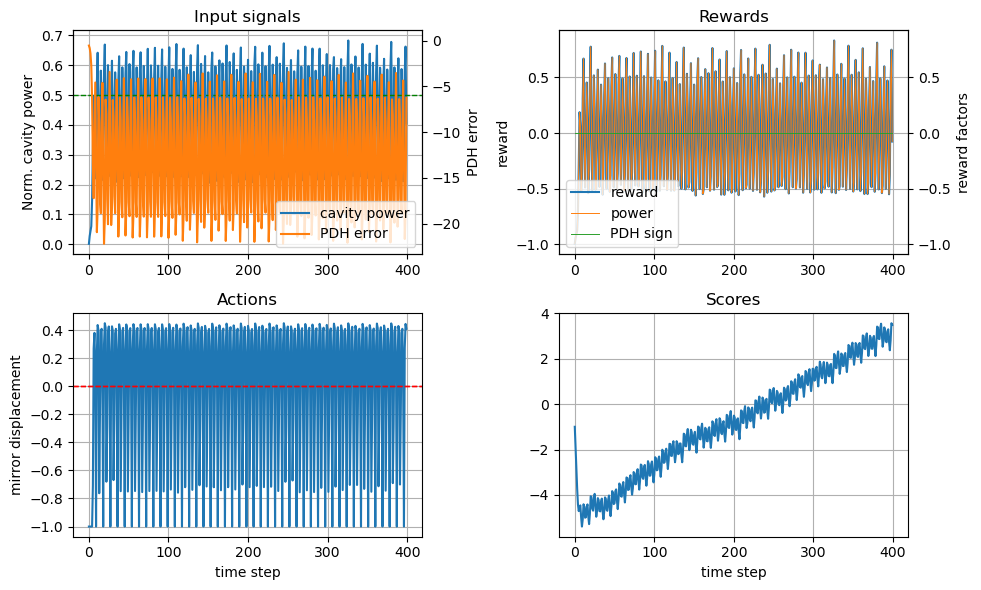

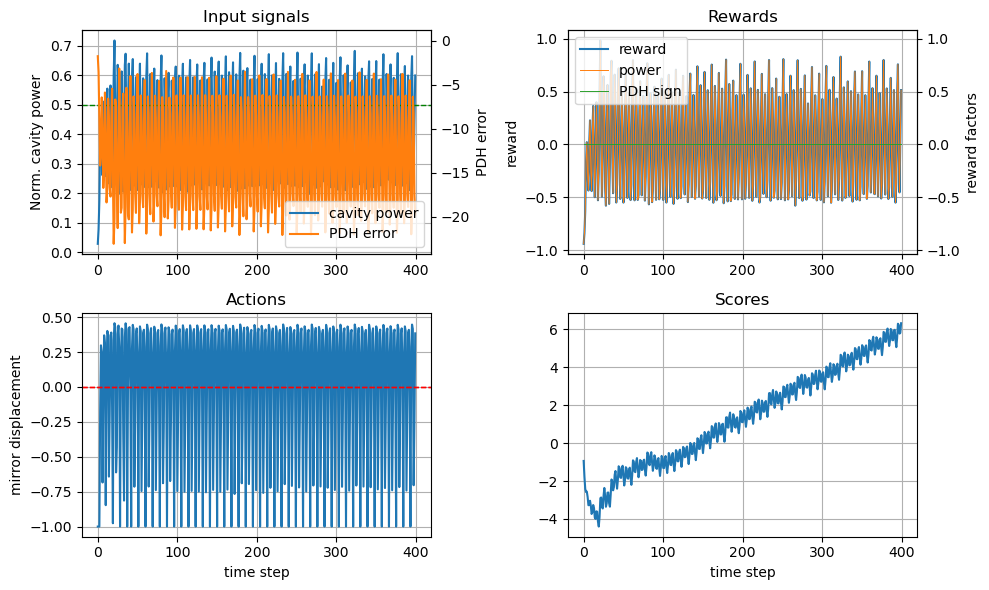

In [56]:
episodes = 2
states = []

plt.rcParams['figure.figsize'] = [10, 6]

fig_file_name = str(datetime.today().strftime('%Y%m%d_%H%M%S'))

for episode in range(1, episodes+1):
    obs, _ = env.reset()
    done = False
    score = 0
    i = 0
    lstm_states = None

    num_envs = 1
    # Episode start signals are used to reset the lstm states
    episode_starts = np.ones((num_envs,), dtype=bool)
    #while not done:
    while i < 400:
        i+=1
        d_zeta, lstm_states = model.predict(obs, state=lstm_states, episode_start=episode_starts, deterministic=True)
        #d_zeta = [2.4637934543840106e-10] # Linear scan trials
        obs, reward, done, info, _ = env.step(np.array(d_zeta, dtype=np.float32))
        states.append(obs)
        score+=reward
    print("Episode:{} Score:{}".format(episode, score))
    fig, axs = env.render()
    fig.savefig(fig_file_name + "_DDPG_episode{0}.pdf".format(episode), bbox_inches='tight')
#plt.plot(np.array(states))
#plt.clf()
#env.close()

In [ ]:
plt.plot(states[90:190])

Possible hyperparameter tuning with optuna. Moreover for huge models it could be helpful to add a callback or reward threshold (EvalCallback, StopTrainingOnRewardThreshold methods in common.callbacks)

View the logs in tensorboard with command: tensorboard --logdir{log_path}. (Installation of tensorboard for some reason doesn't work for me inside the current conda env, pip3 install tensorboard worked for me)

" For A2C and PPO, continuous actions are clipped during training and testing (to avoid out of bound error). SAC, DDPG and TD3 squash the action, using a tanh() transformation, which handles bounds more correctly. " (stablebaselines3 documentation)

### A2C model

In [ ]:
model = A2C("MlpPolicy", env, verbose=1, tensorboard_log=log_path)

In [ ]:
model.learn(total_timesteps=500000) 

In [ ]:
evaluate_policy(model, env , n_eval_episodes=10, render = True)

In [ ]:
env.close()

In [ ]:
episodes = 2
states = []

plt.rcParams['figure.figsize'] = [10, 6]

fig_file_name = str(datetime.today().strftime('%Y%m%d_%H%M%S'))

for episode in range(1, episodes+1):
    obs, _ = env.reset()
    done = False
    score = 0
    while not done:
        d_zeta, _ = model.predict(obs)
        #d_zeta = [2.4637934543840106e-10] # Linear scan trials
        obs, reward, done, info, _ = env.step(np.array(d_zeta, dtype=np.float32))
        states.append(obs)
        score+=reward
    print("Episode:{} Score:{}".format(episode, score))
    fig, axs = env.render()
    fig.savefig(fig_file_name + "_A2C_episode{0}.pdf".format(episode), bbox_inches='tight')
#plt.plot(np.array(states))
#plt.clf()
#env.close()

### PPO Model

In [ ]:
model = PPO("MlpPolicy", env, verbose=1, tensorboard_log=log_path)

In [ ]:
model.learn(total_timesteps=1000000) 

In [ ]:
evaluate_policy(model, env , n_eval_episodes=10, render = True)

In [ ]:
env.close()

In [ ]:
episodes = 20
states = []

plt.rcParams['figure.figsize'] = [10, 6]

fig_file_name = str(datetime.today().strftime('%Y%m%d_%H%M%S'))

for episode in range(1, episodes+1):
    obs, _ = env.reset()
    done = False
    score = 0
    while not done:
        d_zeta, _ = model.predict(obs)
        #d_zeta = [2.4637934543840106e-10] # Linear scan trials
        obs, reward, done, info, _ = env.step(np.array(d_zeta, dtype=np.float32))
        states.append(obs)
        score+=reward
    print("Episode:{} Score:{}".format(episode, score))
    fig, axs = env.render()
    fig.savefig(fig_file_name + "_PPO_episode{0}.pdf".format(episode), bbox_inches='tight')
#plt.plot(np.array(states))
#plt.clf()
#env.close()

In [ ]:
PPO_path = os.path.join('.', 'training', 'saved_models', 'temp', 'PPO_cav_1M')

In [ ]:
model.save(PPO_path)

In [ ]:
del model
env.close()

In [ ]:
model = PPO.load(PPO_path, env=env)